# Atividade — Meios de Transporte

**Arquivo utilizado:** `Tabela_13_Meio_de_transporte.xlsx`  
**Fonte:** abas `Exemplo gráfico Brasil` e `BR GR UF MU`.

> Observação: os percentuais de "em geral" na Parte 2 são calculados como a **média simples das três categorias de cor/raça** (Branca, Preta ou Parda e Indígena), pois a planilha fornece percentuais separados por raça e não apresenta, nessa tabela, uma coluna geral com o total de mulheres.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Caminho do arquivo Excel
arquivo = r"Tabela_13_Meio_de_transporte.xlsx"


## PARTE 1 — Gráfico de pizza por cor/raça

In [15]:
# 2. Leitura da aba "Exemplo gráfico Brasil"
df_grafico = pd.read_excel(
    arquivo,
    sheet_name="Exemplo gráfico Brasil",
    header=1
)

df_grafico.columns = ["Meio de Transporte", "Branca", "Preta ou Parda", "Indígena"]

# Conferindo os dados
df_grafico


,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


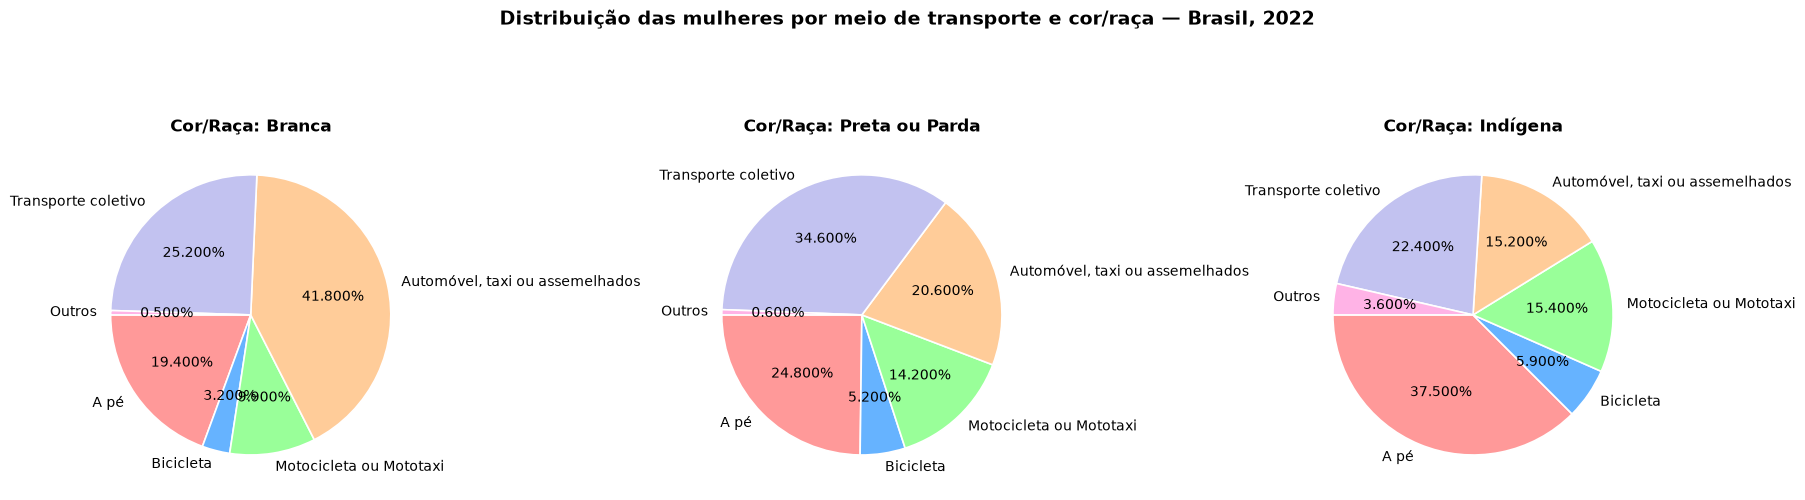

In [16]:
# 3. Pie charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df_grafico[col],
        labels=df_grafico['Meio de Transporte'],
        autopct='%1.3f%%',  # 3 casas decimais
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Distribuição das mulheres por meio de transporte e cor/raça — Brasil, 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300, bbox_inches='tight')
plt.show()


## Análise dos gráficos

As diferenças abaixo estão em **pontos percentuais (p.p.)**. O cálculo é feito subtraindo o percentual da segunda raça do percentual da primeira.

- **A pé:** Brancas − Pretas/Pardas = **−5,4 p.p.**; Brancas − Indígenas = **−18,1 p.p.**; Pretas/Pardas − Indígenas = **−12,7 p.p.**
- **Bicicleta:** Brancas − Pretas/Pardas = **−2,0 p.p.**; Brancas − Indígenas = **−2,7 p.p.**; Pretas/Pardas − Indígenas = **−0,7 p.p.**
- **Motocicleta ou Mototáxi:** Brancas − Pretas/Pardas = **−4,3 p.p.**; Brancas − Indígenas = **−5,5 p.p.**; Pretas/Pardas − Indígenas = **−1,2 p.p.**
- **Automóvel, táxi ou assemelhados:** Brancas − Pretas/Pardas = **+21,2 p.p.**; Brancas − Indígenas = **+26,6 p.p.**; Pretas/Pardas − Indígenas = **+5,4 p.p.**
- **Transporte coletivo:** Brancas − Pretas/Pardas = **−9,4 p.p.**; Brancas − Indígenas = **+2,8 p.p.**; Pretas/Pardas − Indígenas = **+12,2 p.p.**
- **Outros:** Brancas − Pretas/Pardas = **−0,1 p.p.**; Brancas − Indígenas = **−3,1 p.p.**; Pretas/Pardas − Indígenas = **−3,0 p.p.**

**Exemplo:** no uso de automóvel, o percentual de mulheres brancas é **21,2 pontos percentuais maior** que o de mulheres pretas ou pardas (41,8% contra 20,6%).

## PARTE 2 — Estados e municípios

In [10]:
# 1. Leitura da aba "BR GR UF MU"
# header=None é usado porque a planilha possui duas linhas de cabeçalho.
df_br = pd.read_excel(
    arquivo,
    sheet_name="BR GR UF MU",
    header=None
)

# Lista oficial dos 27 estados/UFs presentes na tabela
estados = [
    "Rondônia", "Acre", "Amazonas", "Roraima", "Pará", "Amapá", "Tocantins",
    "Maranhão", "Piauí", "Ceará", "Rio Grande do Norte", "Paraíba",
    "Pernambuco", "Alagoas", "Sergipe", "Bahia", "Minas Gerais",
    "Espírito Santo", "Rio de Janeiro", "São Paulo", "Paraná",
    "Santa Catarina", "Rio Grande do Sul", "Mato Grosso do Sul",
    "Mato Grosso", "Goiás", "Distrito Federal"
]

# 2. Liste apenas os estados
df_estados = df_br[df_br[0].isin(estados)].copy()
df_estados = df_estados.rename(columns={0: "Estado"})

df_estados[["Estado"]]


,Estado
9,Rondônia
10,Acre
11,Amazonas
12,Roraima
13,Pará
14,Amapá
15,Tocantins
16,Maranhão
17,Piauí
18,Ceará


In [11]:
# Preparação dos dados:
# transforma as colunas por raça em formato longo (melt),
# facilitando o uso de groupby nas perguntas.

transportes = [
    "A pé",
    "Bicicleta",
    "Motocicleta ou Mototaxi",
    "Automóvel, taxi ou assemelhados",
    "Transporte coletivo",
    "Outros"
]

# Nomeamos as 18 colunas de percentuais
colunas = ["Estado"] + [
    f"{raca} - {transporte}"
    for raca in ["Branca", "Preta ou Parda", "Indígena"]
    for transporte in transportes
]

df_estados = df_estados.iloc[:, :19].copy()
df_estados.columns = colunas

# Converte os percentuais para números
for c in colunas[1:]:
    df_estados[c] = pd.to_numeric(df_estados[c], errors="coerce")

# MELT
df_estados_melt = df_estados.melt(
    id_vars="Estado",
    var_name="Raca_Transporte",
    value_name="Percentual"
)

df_estados_melt[["Raca", "Transporte"]] = df_estados_melt["Raca_Transporte"].str.split(
    " - ", n=1, expand=True
)

df_estados_melt.head()


,Estado,Raca_Transporte,Percentual,Raca,Transporte
0,Rondônia,Branca - A pé,11.7,Branca,A pé
1,Acre,Branca - A pé,14.8,Branca,A pé
2,Amazonas,Branca - A pé,13.9,Branca,A pé
3,Roraima,Branca - A pé,11.6,Branca,A pé
4,Pará,Branca - A pé,17.5,Branca,A pé


In [ ]:
# GROUPBY:
# média dos percentuais das três raças para cada estado e meio de transporte.

estado_geral = (
    df_estados_melt
    .groupby(["Estado", "Transporte"], as_index=False)["Percentual"]
    .mean()
)

estado_coletivo = (
    estado_geral[estado_geral["Transporte"] == "Transporte coletivo"]
    .sort_values("Percentual", ascending=False)
)

estado_coletivo


### Respostas — transporte coletivo

**Qual estado tem mais mulheres, em geral, utilizando o transporte coletivo?**  
**Rio de Janeiro — 52,23%**, considerando a média simples dos percentuais de Branca, Preta ou Parda e Indígena.

**Qual estado tem menos mulheres, em geral, utilizando o transporte coletivo?**  
**Rondônia — 4,33%**, usando o mesmo critério de média entre as três categorias de raça.

In [ ]:
# Preparação dos municípios:
# as linhas após os 27 estados correspondem aos municípios.
df_municipios = df_br.iloc[36:, :19].copy()
df_municipios = df_municipios[df_municipios[0].notna()].copy()
df_municipios = df_municipios.rename(columns={0: "Cidade"})

# Mesma estrutura de colunas usada para os estados
df_municipios.columns = colunas[:1] + colunas[1:]
df_municipios = df_municipios.rename(columns={"Estado": "Cidade"})

for c in df_municipios.columns[1:]:
    df_municipios[c] = pd.to_numeric(df_municipios[c], errors="coerce")

# MELT dos municípios
df_municipios_melt = df_municipios.melt(
    id_vars="Cidade",
    var_name="Raca_Transporte",
    value_name="Percentual"
)

df_municipios_melt[["Raca", "Transporte"]] = df_municipios_melt["Raca_Transporte"].str.split(
    " - ", n=1, expand=True
)

df_municipios_melt.head()


In [12]:
# GROUPBY:
# média dos percentuais das três raças para cada cidade e transporte.

cidade_geral = (
    df_municipios_melt
    .groupby(["Cidade", "Transporte"], as_index=False)["Percentual"]
    .mean()
)

# Cidade com maior percentual médio de mulheres utilizando bicicleta
maior_bicicleta = (
    cidade_geral[cidade_geral["Transporte"] == "Bicicleta"]
    .dropna(subset=["Percentual"])
    .sort_values("Percentual", ascending=False)
    .head(1)
)

# Cidade com maior percentual médio de mulheres utilizando carro
maior_carro = (
    cidade_geral[cidade_geral["Transporte"] == "Automóvel, taxi ou assemelhados"]
    .dropna(subset=["Percentual"])
    .sort_values("Percentual", ascending=False)
    .head(1)
)

print("Maior percentual médio de bicicleta:")
display(maior_bicicleta)

print("Maior percentual médio de carro:")
display(maior_carro)


NameError: name 'df_municipios_melt' is not defined

### Respostas — municípios

**Qual cidade do Brasil tem mais mulheres andando de bicicleta?**  
**Tuiuti (SP) — 100,00%**, pela média dos percentuais das três categorias de cor/raça.

**Qual cidade do Brasil tem mais mulheres utilizando carro?**  
**Bom Jesus do Oeste (SC) — 86,05%**, pela média dos percentuais das três categorias de cor/raça.

## Conclusão

A análise mostra diferenças relevantes entre os meios de transporte segundo a cor/raça. No Brasil, o automóvel apresenta percentual mais alto entre mulheres brancas, enquanto o transporte coletivo apresenta percentual mais alto entre mulheres pretas ou pardas. Na análise municipal, os maiores percentuais encontrados foram **Tuiuti (SP)** para bicicleta e **Bom Jesus do Oeste (SC)** para automóvel, usando a média simples das três categorias de cor/raça.